<div style="background-color:#0A2B07;">
  <h1 style="margin:auto; padding:20px 0; color:#fff; text-align:center; font-weight:bold;">
    PROJET 5 DATA SCIENTIST
  </h1>
  <h2 style="margin:auto; padding:20px 0; color:#fff; text-align:center; font-weight:bold;">
    Segmentez des clients d'un site e-commerce
  </h2>
</div>


## **INITIALISATION**

In [41]:
# ============================================================
# LIBRAIRIES STANDARD
# ============================================================

from datetime import datetime
import joblib

# ============================================================
# MANIPULATION DE DONNÉES
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# VISUALISATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# MACHINE LEARNING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np


In [4]:
# Définir le dossier où sont stockés les fichiers CSV
data_path = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# Charger tous les fichiers CSV en utilisant le chemin centralisé
customers = pd.read_csv(f"{data_path}\\olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{data_path}\\olist_geolocation_dataset.csv")
order_items = pd.read_csv(f"{data_path}\\olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{data_path}\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{data_path}\\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{data_path}\\olist_orders_dataset.csv")
products = pd.read_csv(f"{data_path}\\olist_products_dataset.csv")
sellers = pd.read_csv(f"{data_path}\\olist_sellers_dataset.csv")


In [5]:
def profile_dataframe(df, table_name, primary_keys=None, verbose=True):
    """
    Profiling complet d'un DataFrame avec informations sur les colonnes
    et éventuellement sur la clé primaire, avec quartiles pour les colonnes numériques et dates.

    Arguments :
        df : DataFrame à analyser
        table_name : nom logique de la table (string)
        primary_keys : dictionnaire {nom_table: [liste_colonnes_identifiants]}
        verbose : bool, si True affiche les infos générales
    
    Retour :
        DataFrame contenant pour chaque colonne :
        - première valeur
        - type pandas
        - type détaillé (numérique, texte, date, booléen)
        - nombre de valeurs uniques
        - % doublons si clé primaire
        - % valeurs manquantes
        - % zéros (numérique)
        - min, max, médiane
        - 1er quartile (25%), 3ème quartile (75%)
        - moyenne (numérique)
    """
    n_rows, n_cols = df.shape

    # Gestion clé primaire
    pk_cols = []
    n_duplicates = None
    if primary_keys and table_name in primary_keys:
        pk_cols = [c for c in primary_keys[table_name] if c in df.columns]
        if pk_cols:
            n_duplicates = df.duplicated(subset=pk_cols, keep=False).sum()
    
    if verbose:
        print(f"\n=== Table : {table_name} ===")
        print(f"Taille : {n_rows} lignes × {n_cols} colonnes")
        if pk_cols:
            pk_str = "', '".join(pk_cols)
            print(f"Clé primaire : '{pk_str}' → {n_duplicates} doublons")
        else:
            if primary_keys and table_name in primary_keys:
                print("Clé primaire définie dans primary_keys mais colonnes manquantes dans le DataFrame")
            else:
                print("Clé primaire : non renseignée")
    
    results = []
    
    for col in df.columns:
        serie = df[col]
        first_value = serie.iloc[0]
        dtype = serie.dtype

        # type détaillé
        if pd.api.types.is_numeric_dtype(serie):
            detailed_type = "numérique"
        elif pd.api.types.is_bool_dtype(serie):
            detailed_type = "booléen"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            detailed_type = "date"
        else:
            detailed_type = "texte"
        
        n_unique = serie.nunique(dropna=False)
        pct_missing = round(serie.isna().mean() * 100, 2)
        
        if detailed_type == "numérique":
            pct_zeros = round((serie == 0).mean() * 100, 2)
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = round(serie.mean(), 2)
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        elif detailed_type == "date":
            pct_zeros = np.nan
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = np.nan
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        else:
            pct_zeros = np.nan
            col_min = np.nan
            col_max = np.nan
            median = np.nan
            mean = np.nan
            q25 = np.nan
            q75 = np.nan

        pct_duplicates = np.nan
        if col in pk_cols:
            pct_duplicates = round((1 - serie.nunique(dropna=False) / n_rows) * 100, 2)
        
        results.append({
            "column": col,
            "first_value": first_value,
            "dtype": dtype,
            "detailed_type": detailed_type,
            "n_unique": n_unique,
            "pct_duplicates": pct_duplicates,
            "pct_missing": pct_missing,
            "pct_zeros": pct_zeros,
            "min": col_min,
            "q25": q25,
            "median": median,
            "q75": q75,
            "max": col_max,
            "mean": mean
        })

    if verbose:
        print("\n--- Tableau de profil ---")
    
    return pd.DataFrame(results)


In [37]:
def plot_distributions(
    df,
    columns,
    table_name="Table",
    save_path=None,
    show_values=None,
    color_dict=None,
    agg_col=None
):
    """
    Affiche la distribution d'une ou plusieurs colonnes d'un DataFrame.

    La fonction gère plusieurs cas :
    1. Colonne "raw" (une ligne = un client / observation)
        - Numérique / date : histogramme + boxplot
        - Catégoriel : barplot avec counts / % selon show_values
    2. Colonne déjà agrégée (DataFrame avec effectifs)
        - agg_col doit être fourni (colonne contenant les effectifs)
        - barplot avec counts / % affichés au-dessus des barres

    Paramètres
    ----------
    df : pandas.DataFrame
        DataFrame contenant les données à visualiser.

    columns : list[str] ou str
        Nom(s) des colonnes à tracer. Chaque colonne est traitée séparément.

    table_name : str, optionnel
        Nom logique de la table, utilisé dans le titre des graphiques.

    save_path : str, optionnel
        Chemin pour sauvegarder la figure (PNG, fond transparent).

    show_values : dict, optionnel
        Dictionnaire de configuration des annotations par colonne.
        Clé   : nom de la colonne (str)
        Valeur: type d’annotation à afficher
                - "count"   : effectifs
                - "percent" : pourcentage
                - "both"    : effectifs et %
        Pour les numériques, l’annotation correspond aux counts par bin.

    color_dict : dict, optionnel
        Couleurs personnalisées pour les barplots catégoriels.
        Mapping : valeur de catégorie → couleur.

    agg_col : str, optionnel
        Si le DataFrame contient déjà les effectifs par catégorie, nom de cette colonne.

    Notes
    -----
    - Chaque colonne génère sa propre figure.
    - Pour un DataFrame agrégé (avec agg_col), show_values contrôle l'affichage des counts/%.
    - Pour un DataFrame "raw", show_values contrôle uniquement les colonnes catégorielles et les bins numériques.
    """

    # S'assurer que columns est une liste
    if isinstance(columns, str):
        columns = [columns]

    show_values = show_values or {}

    # Boucle sur chaque colonne
    for col in columns:
        if col not in df.columns:
            print(f"Colonne '{col}' non trouvée.")
            continue

        plt.figure(figsize=(12,5))
        col_tex = col.replace("_", r"\_")
        table_tex = table_name.replace("_", r"\_")
        title_str = (
            fr"Distribution de la variable $\mathbf{{\mathit{{{col_tex}}}}}$ "
            fr"de la table $\mathbf{{\mathit{{{table_tex}}}}}$"
        )

        # ------------------------------
        # Cas DataFrame déjà agrégé
        # ------------------------------
        if agg_col is not None:
            x = df[col]         # catégories
            y = df[agg_col]     # hauteurs des barres (effectifs)
            total = y.sum()

            colors = [color_dict.get(v, "forestgreen") for v in x] if color_dict else ["forestgreen"]*len(x)
            ax = sns.barplot(x=x, y=y, palette=colors)
            plt.title(title_str)
            plt.ylabel("Fréquence")
            plt.xticks(rotation=45)

            # Ajustement axe Y pour laisser de la place aux annotations
            ymax = max(y)
            ax.set_ylim(0, ymax*1.15)

            # Annotations au-dessus des barres
            mode = show_values.get(col)
            if mode:
                for i, v in enumerate(y):
                    pct = v / total * 100
                    if mode=="count":
                        label = f"{v}"
                    elif mode=="percent":
                        label = f"{pct:.1f}%"
                    elif mode=="both":
                        label = f"{v} ({pct:.1f}%)"
                    else:
                        continue
                    ax.text(i, v + ymax*0.02, label, ha="center", va="bottom", fontsize=9)

            plt.tight_layout()
            if save_path: plt.savefig(save_path, transparent=True)
            plt.show()
            continue

        # ------------------------------
        # Cas DataFrame "raw"
        # ------------------------------
        serie = df[col]

        # Détection du type
        if pd.api.types.is_numeric_dtype(serie):
            type_col = "numérique"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            type_col = "date"
        else:
            type_col = "catégoriel"

        # ----- Numérique / Date -----
        if type_col in ["numérique", "date"]:
            plt.subplot(1,2,1)
            mode = show_values.get(col)

            # Si on veut afficher count/% au-dessus des bins
            if mode:
                counts, bins, _ = plt.hist(serie, bins=30, color="forestgreen", alpha=0.6)
                total = counts.sum()
                for i, (c, left, right) in enumerate(zip(counts, bins[:-1], bins[1:])):
                    pct = c / total * 100
                    if mode=="count":
                        label = f"{int(c)}"
                    elif mode=="percent":
                        label = f"{pct:.1f}%"
                    elif mode=="both":
                        label = f"{int(c)} ({pct:.1f}%)"
                    else:
                        continue
                    # texte centré sur la barre
                    plt.text((left+right)/2, c + max(counts)*0.01, label, ha="center", va="bottom", fontsize=9)
            else:
                plt.hist(serie, bins=30, color="forestgreen", alpha=0.6)

            plt.title(title_str)
            plt.ylabel("Fréquence")

            # Boxplot à côté
            plt.subplot(1,2,2)
            sns.boxplot(x=serie, color="forestgreen")
            plt.title("Boxplot")
            plt.tight_layout()
            if save_path: plt.savefig(save_path, transparent=True)
            plt.show()

        # ----- Catégoriel -----
        else:
            counts = serie.value_counts()
            total = counts.sum()
            colors = [color_dict.get(v,"forestgreen") for v in counts.index] if color_dict else ["forestgreen"]*len(counts)

            ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
            plt.title(title_str)
            plt.ylabel("Fréquence")
            plt.xticks(rotation=45)

            # Ajustement axe Y
            ymax = counts.max()
            ax.set_ylim(0, ymax*1.15)

            # Annotations
            mode = show_values.get(col)
            if mode:
                for i, v in enumerate(counts.values):
                    pct = v / total * 100
                    if mode=="count":
                        label = f"{v}"
                    elif mode=="percent":
                        label = f"{pct:.1f}%"
                    elif mode=="both":
                        label = f"{v} ({pct:.1f}%)"
                    else:
                        continue
                    ax.text(i, v + ymax*0.02, label, ha="center", va="bottom", fontsize=9)

            plt.tight_layout()
            if save_path: plt.savefig(save_path, transparent=True)
            plt.show()


# # ==============================
# # Exemple d'utilisation : segments clients
# # ==============================

# # Définition des couleurs pour chaque segment
# color_segment = {
#     "loyaux": "#2851FF",
#     "loyalistes potentiels": "#092AAE",
#     "Champions": "#15C574",
#     "a réactiver": "#1D8C56",
#     "perdus": "#910909",
#     "a risque": "#E72C26"
# }

# # --- Affichage des effectifs et pourcentages au-dessus des barres ---
# plot_distributions(
#     df=rfm_v2,                          # DataFrame raw (une ligne par client)
#     columns=["segment"],                # colonne à tracer
#     table_name="rfm_v2",
#     show_values={"segment": "both"},    # affiche count + %
#     color_dict=color_segment            # couleurs personnalisées
# )


In [7]:
def value_frequencies(df, column):
    """
    Affiche un tableau avec la fréquence des valeurs uniques d'une colonne.
    """
    if column not in df.columns:
        print(f"Colonne '{column}' non trouvée dans le DataFrame.")
        return
    
    freqs = df[column].value_counts(dropna=False)
    freq_table = pd.DataFrame({
        "valeur": freqs.index,
        "fréquence": freqs.values,
        "pourcentage": (freqs.values / len(df) * 100).round(2)
    })
    return freq_table


# **CADRAGE**

**Objectif métier de la segmentation**
- Identifier des groupes de clients homogènes pour adapter les actions marketing

**Usage marketing attendu**
- Campagnes ciblées, offres personnalisées, priorisation des clients, relances, fidélisation

**Contraintes**
- Interprétabilité : les segments doivent pouvoir être expliqués aux équipes marketing
- Stabilité : segmentation stable dans le temps pour comparer les clusters
- Recalcul : prévoir la fréquence et la méthode pour mettre à jour la segmentation


# **ANALYSE EXPLORATOIRE ET NETTOYAGE DES DONNÉES**

In [8]:
print('customer', customers.columns.tolist())
print('geolocation', geolocation.columns.tolist())
print('order_items', order_items.columns.tolist())
print('order_payments', order_payments.columns.tolist())
print('order_reviews', order_reviews.columns.tolist())
print('orders', orders.columns.tolist())
print('products', products.columns.tolist())
print('sellers', sellers.columns.tolist())

customer ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geolocation ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
order_items ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
order_payments ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
order_reviews ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
orders ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
products ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', '

In [9]:
primary_keys = {
    "customers": ["customer_unique_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_city"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"]
}

### **CUSTOMER**

In [10]:
# # Suppression des doublons sur customer_unique_id
# # customers = customers.drop_duplicates(subset=['customer_unique_id'], keep='first')

# # Affichage du profil
# profile_customers = profile_dataframe(customers, "customers", primary_keys)
# display(profile_customers)

# # Affichage de la distribution
# plot_distributions(customers, "customer_state", table_name="customers")

### **GEOLOCALISATION**

In [11]:
# Suppression des doublons
geolocation = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_city'], keep='first')

# # Affichage du profil
# profile_geolocation = profile_dataframe(geolocation, "geolocation", primary_keys)
# # display(profile_geolocation)

# # Affichage de la distribution
# plot_distributions(geolocation, "geolocation_state", table_name="geolocation")

### **ORDER_ITEMS**

In [12]:
# Conversion des colonnes de date
cols_to_convert = ['shipping_limit_date']
order_items[cols_to_convert] = order_items[cols_to_convert].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# # Affichage du profil
# profile_order_items = profile_dataframe(order_items, "order_items", primary_keys)
# display(profile_order_items)

# # Affichage de la distribution
# plot_distributions(order_items, ["price", "freight_value", "order_item_id"], table_name="order_items")

### **ORDER_PAYMENTS**

In [13]:
# # Affichage du profil
# profile_order_payments = profile_dataframe(order_payments, "order_payments", primary_keys)
# display(profile_order_payments)

# # Affichage de la distribution
# plot_distributions(order_payments, ["payment_sequential", "payment_type", "payment_value"], table_name="order_payments")

### **ORDER_REVIEW**

In [14]:
# Suppression des doublons sur review_id
# order_reviews = order_reviews.drop_duplicates(subset=['review_id'], keep='first')

# Conversion des colonnes de date
cols_to_convert = ['review_creation_date', 'review_answer_timestamp']
order_reviews[cols_to_convert] = order_reviews[cols_to_convert].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_order_reviews = profile_dataframe(order_reviews, "order_reviews", primary_keys)
# display(profile_order_reviews)

# # Affichage de la distribution
# plot_distributions(order_reviews, "review_score", table_name="order_reviews")


### **ORDERS**

In [15]:
# Conversion des colonnes de date
cols_to_convert_orders = ['order_purchase_timestamp', 'order_approved_at', 
                          'order_delivered_carrier_date', 'order_delivered_customer_date', 
                          'order_estimated_delivery_date']
orders[cols_to_convert_orders] = orders[cols_to_convert_orders].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_orders = profile_dataframe(orders, "orders", primary_keys)
# display(profile_orders)

# # Affichage de la distribution
# plot_distributions(orders, ["order_status", "order_purchase_timestamp", "order_delivered_customer_date"], table_name="orders")

### **PRODUCTS**

In [16]:
# # Affichage du profil
# profile_products = profile_dataframe(products, "products", primary_keys)
# display(profile_products)

# # Affichage de la distribution
# plot_distributions(products, ["product_weight_g", "product_length_cm"], table_name="products")

In [17]:
# value_frequencies(products, "product_category_name")

### **SELLERS**

In [18]:
# # Affichage du profil
# profile_sellers = profile_dataframe(sellers, "sellers", primary_keys)
# display(profile_sellers)

# # Affichage de la distribution
# plot_distributions(sellers, "seller_state", table_name="sellers")

# **K-MEANS_V1**

### **FEATURE ENGINEERING**

In [19]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE (MONETARY)
# ============================================================

order_value = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),
        freight_total=('freight_value', 'sum')
    )
)

# Montant total commande = produits + frais de port
order_value['order_total_value'] += order_value['freight_total']


# ============================================================
# 2. ENRICHISSEMENT DES COMMANDES
# ============================================================

orders_rfm = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp']
)


# ============================================================
# 3. AGRÉGATION CLIENT — VARIABLES RFM
# ============================================================

df_rfm = (
    orders_rfm
    .groupby('customer_unique_id', as_index=False)
    .agg(
        frequency=('order_id', 'nunique'),                 # Nombre de commandes
        monetary=('order_total_value', 'sum'),             # Dépense totale
        last_order_date=('order_purchase_timestamp', 'max')
    )
)


# ============================================================
# 4. CALCUL DE LA RECENCY
# ============================================================

# Date de référence = dernière date de commande du dataset
reference_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    reference_date - df_rfm['last_order_date']
).dt.days


# ============================================================
# 5. TABLE FINALE RFM
# ============================================================

df_rfm = df_rfm[[
    'customer_unique_id',
    'frequency',
    'recency',
    'monetary'
]]



=== Table : df_rfm ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,1,int64,numérique,9,NaN,0.0,0.0,1.0,1.00,1.00,1.0000,17.00,1.03
2,recency,160,int64,numérique,630,NaN,0.0,0.0,0.0,163.00,268.00,397.0000,772.00,287.74
3,monetary,141.9,float64,numérique,31718,NaN,0.0,0.7,0.0,62.39,107.27,182.2375,13664.08,164.87


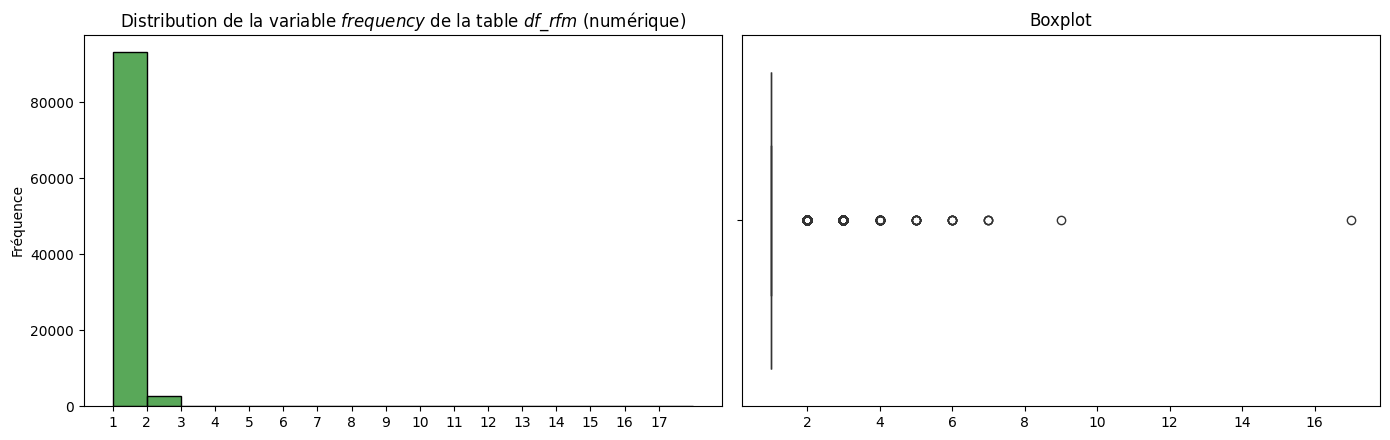

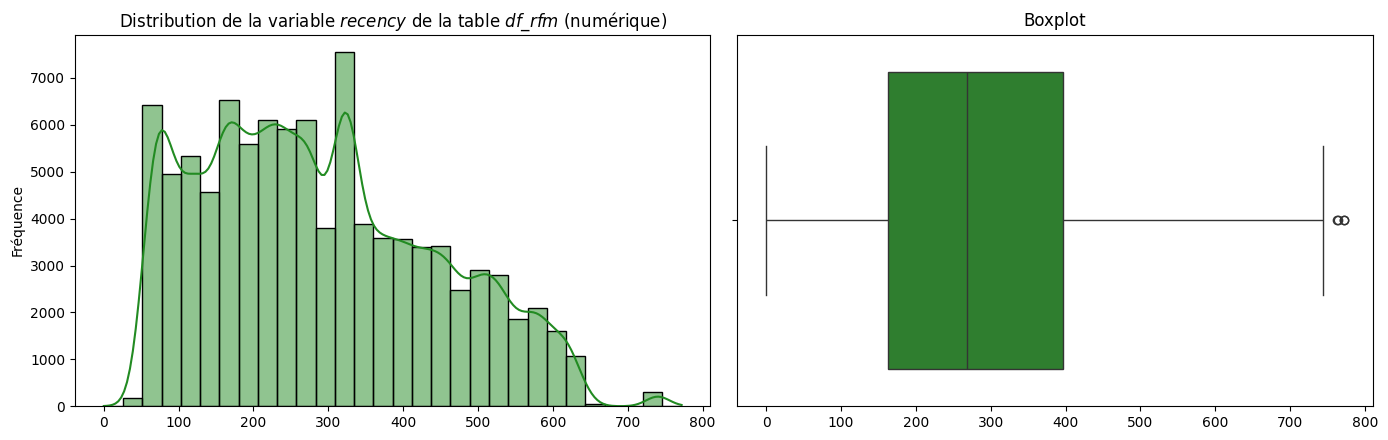

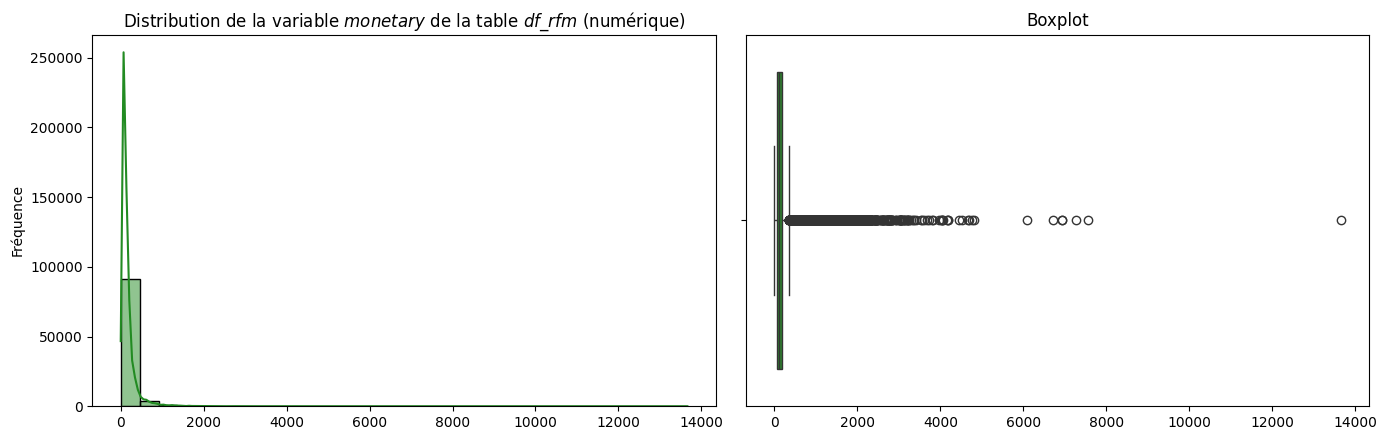

In [20]:
# ==============================
# PROFIL
# ==============================

# --- Profil du dataframe ---
profile_df_rfm = profile_dataframe(df_rfm, "df_rfm")
display(profile_df_rfm)

# --- Affichage des distributions ---
plot_distributions(df_rfm, ['frequency', 'recency', 'monetary'], table_name="df_rfm")

### **ENTRAÎNEMENT**

In [21]:
# ==============================
# PRÉPARATION DES DONNÉES POUR K-MEANS
# ==============================

# --- Copie de travail ---
df_k_means_v1 = df_rfm.copy()

# --- Exclusion explicite de l'identifiant ---
id_col = 'customer_unique_id'
df_k_means_v1 = df_k_means_v1.drop(columns=[id_col])

# --- Sélection uniquement des colonnes numériques ---
df_k_means_v1 = df_k_means_v1.select_dtypes(include=['int64', 'float64'])

# --- Standardisation des variables RFM ---
scaler = StandardScaler()
df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)

# --- Vérification finale ---
print("Shape df_k_means_v1 :", df_k_means_v1.shape)

profile_df_k_means_v1 = profile_dataframe(
    df_k_means_v1,
    "df_k_means_v1",
    primary_keys=None
)
display(profile_df_k_means_v1)

Shape df_k_means_v1 : (96096, 3)

=== Table : df_k_means_v1 ===
Taille : 96096 lignes × 3 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


C:\Users\barre\AppData\Local\Temp\ipykernel_14884\85560586.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.16236828 -0.16236828 -0.16236828 ... -0.16236828 -0.16236828
 -0.16236828]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)
C:\Users\barre\AppData\Local\Temp\ipykernel_14884\85560586.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.83262149 -0.81306654  1.93766244 ...  2.14624852 -0.78047497
  1.59219173]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.0,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.0
1,recency,-0.832621,float64,numérique,630,NaN,0.0,0.0,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.0
2,monetary,-0.100783,float64,numérique,31227,NaN,0.0,0.0,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.0


In [ ]:
# # ==============================
# # SILOUETTE SCORE
# # ==============================

# # --- Paramètres ---
# range_n_clusters = range(2, 8)
# silhouette_scores = []
# random_state = 42  # Pour reproductibilité

# # Préparer les données pour le clustering (ignore colonne cluster si elle existe)
# df_for_clustering = df_k_means_v1.drop(columns=['cluster_init'], errors='ignore')

# # --- Calcul des scores silhouette ---
# for k in range_n_clusters:
#     kmeans = KMeans(n_clusters=k, random_state=random_state)
#     labels = kmeans.fit_predict(df_for_clustering)
#     score = silhouette_score(df_for_clustering, labels)
#     silhouette_scores.append(score)

# # --- Affichage de la courbe ---
# plt.figure(figsize=(6,4))
# plt.plot(
#     range_n_clusters,
#     silhouette_scores,
#     marker='o',
#     color='darkgreen'  # <-- couleur vert sapin
# )
# plt.title("Silhouette score en fonction du nombre de clusters")
# plt.xlabel("Nombre de clusters")
# plt.ylabel("Silhouette score")
# plt.grid(True)
# plt.show()

# # --- Tableau des résultats ---
# results_df = pd.DataFrame({
#     "n_clusters": list(range_n_clusters),
#     "silhouette_score": silhouette_scores
# })
# display(results_df)

# # --- Meilleur nombre de clusters selon silhouette ---
# best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
# print("Nombre optimal de clusters selon silhouette :", best_k)


n_clusters	silhouette_score

0	2	0.734130

1	3	0.454816

2	4	0.487504

3	5	0.417231

4	6	0.436395

5	7	0.445165

Nombre optimal de clusters selon silhouette : 2

In [22]:
# ==============================
# K-MEANS À 4 CLUSTERS
# ==============================

n_clusters_4 = 4
random_state = 42

# --- Fit KMeans 4 clusters ---
kmeans_rfm_4_clusters = KMeans(n_clusters=n_clusters_4, random_state=random_state)
df_k_means_v1['cluster'] = kmeans_rfm_4_clusters.fit_predict(df_k_means_v1.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_rfm_4_clusters.inertia_
sil_score = silhouette_score(df_k_means_v1.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means_v1['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means_v1['cluster'].value_counts())

Inertia (somme des distances au centre) : 95724.27
Silhouette score : 0.488

Distribution des clusters :
cluster
0    52073
1    38558
2     2963
3     2502
Name: count, dtype: int64


Inertia (somme des distances au centre) : 95724.27
- Silhouette score : 0.488

Distribution des clusters :
- 0    52073
- 1    38558
- 2     2963
- 3     2502

In [23]:
# ==============================
# SAUVEGARDE DATAFRAME ET MODELE K-MEANS
# ==============================

# chemin raw string
path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# sauvegarde du DataFrame
df_k_means_v1.to_csv(f"{path_data}/df_k_means_v1.csv", index=False)

# sauvegarde du modèle KMeans
joblib.dump(kmeans_rfm_4_clusters, f"{path_data}/kmeans_rfm_4_clusters.joblib")


['C:\\Users\\barre\\Documents\\Pro\\Reconversion_professionnelle\\Formations\\Data_Scientist_by_Openclassrooms\\P05\\data/kmeans_rfm_4_clusters.joblib']

In [24]:
# ==============================
# RECHARGEMENT DATAFRAME ET MODELE K-MEANS
# ==============================

path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# rechargement du DataFrame
df_k_means_v1 = pd.read_csv(f"{path_data}/df_k_means_v1.csv")

# rechargement du modèle
kmeans_rfm_4_clusters = joblib.load(f"{path_data}/kmeans_rfm_4_clusters.joblib")


### **INTERPRÉTATION DES CLUSTERS**


=== Table : df_k_means_v1 ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.00,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.00
1,recency,-0.832621,float64,numérique,630,NaN,0.0,0.00,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.00
2,monetary,-0.100783,float64,numérique,30586,NaN,0.0,0.00,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.00
3,cluster,0.000000,int64,numérique,4,NaN,0.0,54.19,0.000000,0.000000,0.000000,1.000000,3.000000,0.54


,recency,monetary,frequency
cluster,,,
0,-0.72,-0.13,-0.16
1,0.98,-0.14,-0.16
2,-0.13,0.53,5.05
3,0.01,4.39,-0.09


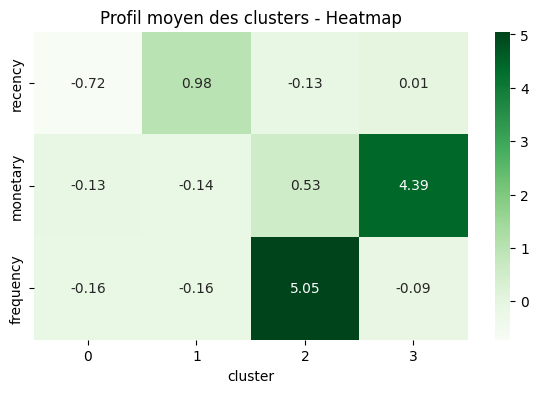

In [ ]:
# ==============================
# PROFIL DU DATAFRAME
# ==============================

# Profil complet du dataframe
df_profile = profile_dataframe(df_k_means_v1, table_name="df_k_means_v1")
display(df_profile)

# Profil moyen par cluster pour toutes les variables continues
cols_continuous = ['recency', 'monetary', 'frequency', 'review_score']
cols_continuous = [c for c in cols_continuous if c in df_k_means_v1.columns]

cluster_means = df_k_means_v1.groupby('cluster')[cols_continuous].mean().round(2)
display(cluster_means)

# Heatmap du profil moyen
plt.figure(figsize=(7, 4))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="Greens")
plt.title("Profil moyen des clusters - Heatmap")
plt.show()


,cluster,nb_clients
0,0,52073
1,1,38558
2,2,2963
3,3,2502


C:\Users\barre\AppData\Local\Temp\ipykernel_14884\1313166627.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x, y=y, palette=colors)


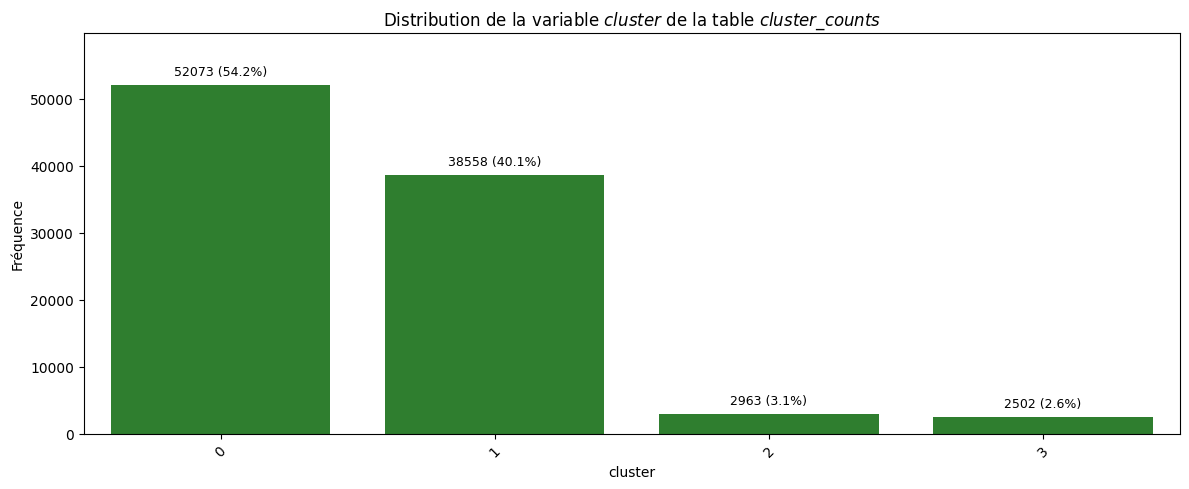

In [ ]:
# ==============================
# 2. RÉPARTITION DES CLIENTS
# ==============================

# Tableau chiffré des effectifs
cluster_counts = df_k_means_v1['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'nb_clients']
display(cluster_counts)

# Barplot
plot_distributions(
    df=cluster_counts,
    columns=["cluster"],                # colonne catégorielle à tracer
    table_name="cluster_counts",
    show_values={"cluster": "both"},    # affiche count + %
    agg_col="nb_clients"                # colonne contenant les effectifs
)


cluster,0,1
count,93088.00,3008.00
mean,0.00,-0.13
std,1.00,0.95
min,-1.88,-1.88
25%,-0.81,-0.89
50%,-0.12,-0.26
75%,0.72,0.52
max,3.16,2.95


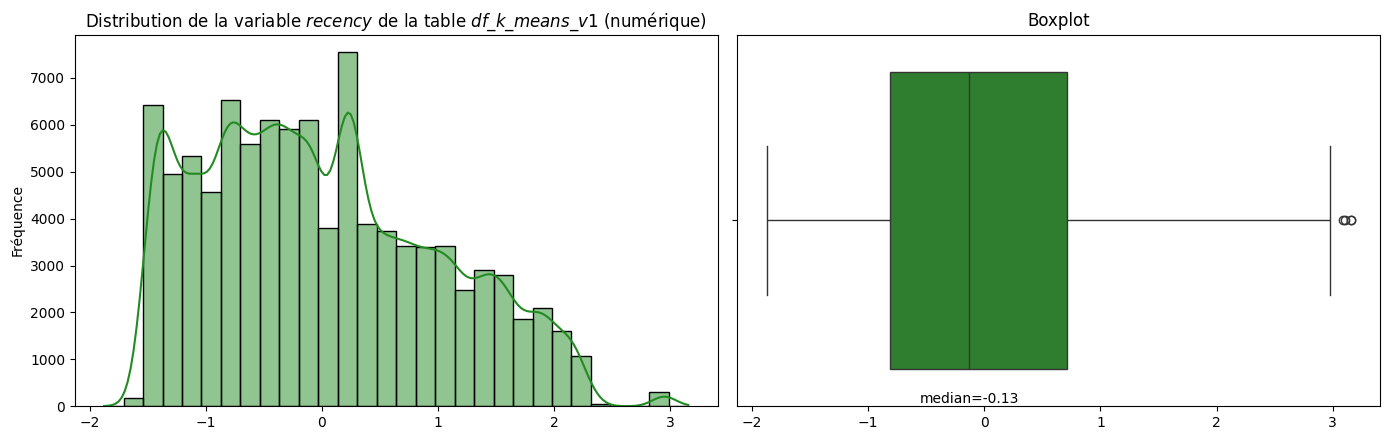

cluster,0,1
count,93088.00,3008.00
mean,-0.02,0.72
std,0.92,2.27
min,-0.72,-0.72
25%,-0.45,-0.09
50%,-0.26,0.26
75%,0.05,0.86
max,17.68,59.22


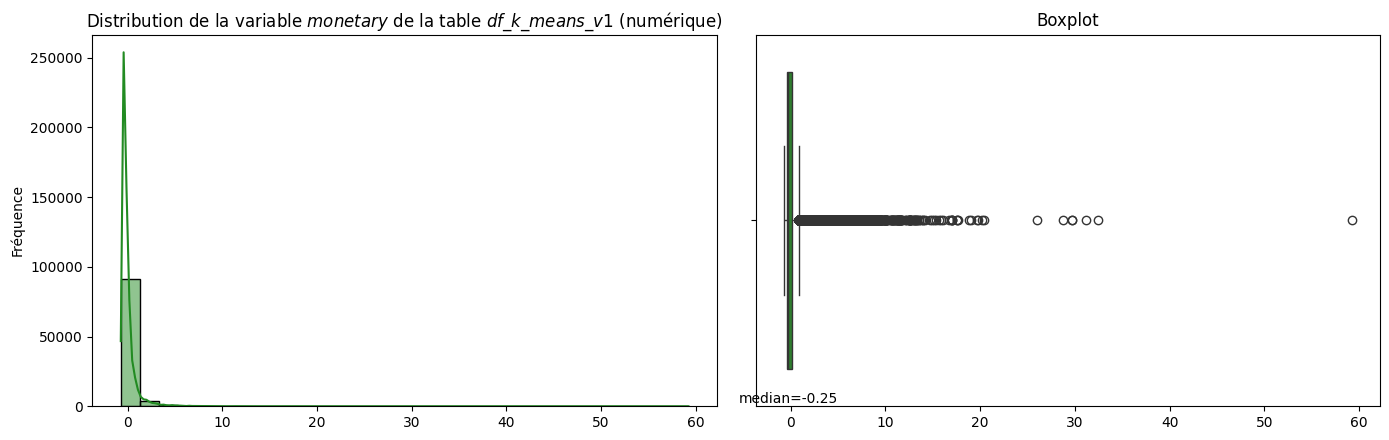

cluster,0,1
count,93088.00,3008.00
mean,-0.16,5.02
std,0.00,2.43
min,-0.16,-0.16
25%,-0.16,4.50
50%,-0.16,4.50
75%,-0.16,4.50
max,-0.16,74.47


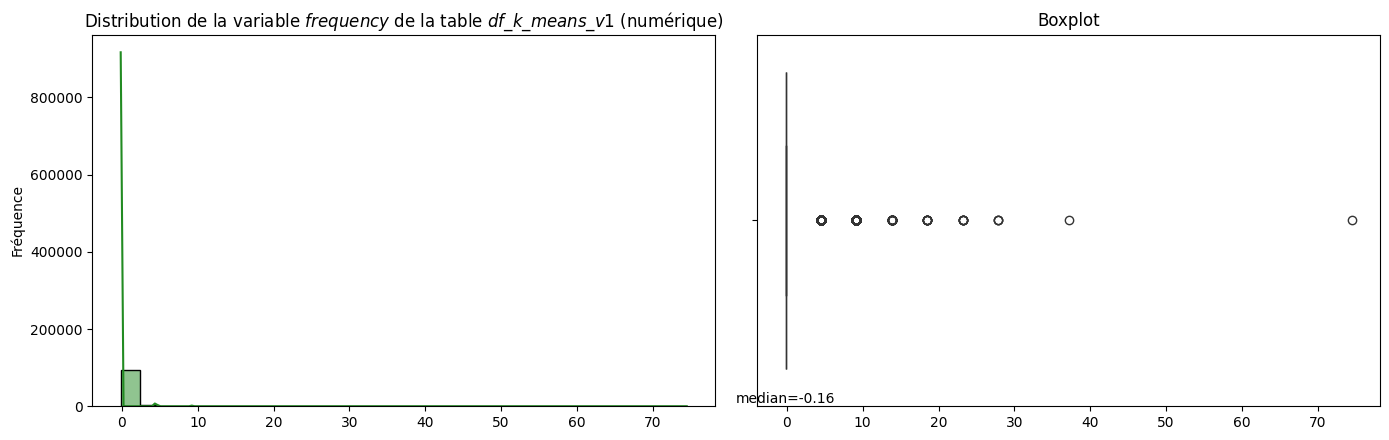

In [96]:
# ==============================
# 3. DISTRIBUTIONS DES VARIABLES
# ==============================

features_to_plot = ['recency', 'monetary', 'frequency']
features_to_plot = [f for f in features_to_plot if f in df_k_means_v1.columns]

# Boucle boxplots + tableau chiffré
for feature in features_to_plot:
    # Tableau descriptif par cluster
    desc = df_k_means_v1.groupby('cluster')[feature].describe().T.round(2)
    display(desc)

    # Boxplot
    plot_distributions(
        df=df_k_means_v1,
        columns=feature,
        table_name="df_k_means_v1",
        show_values=True
    )


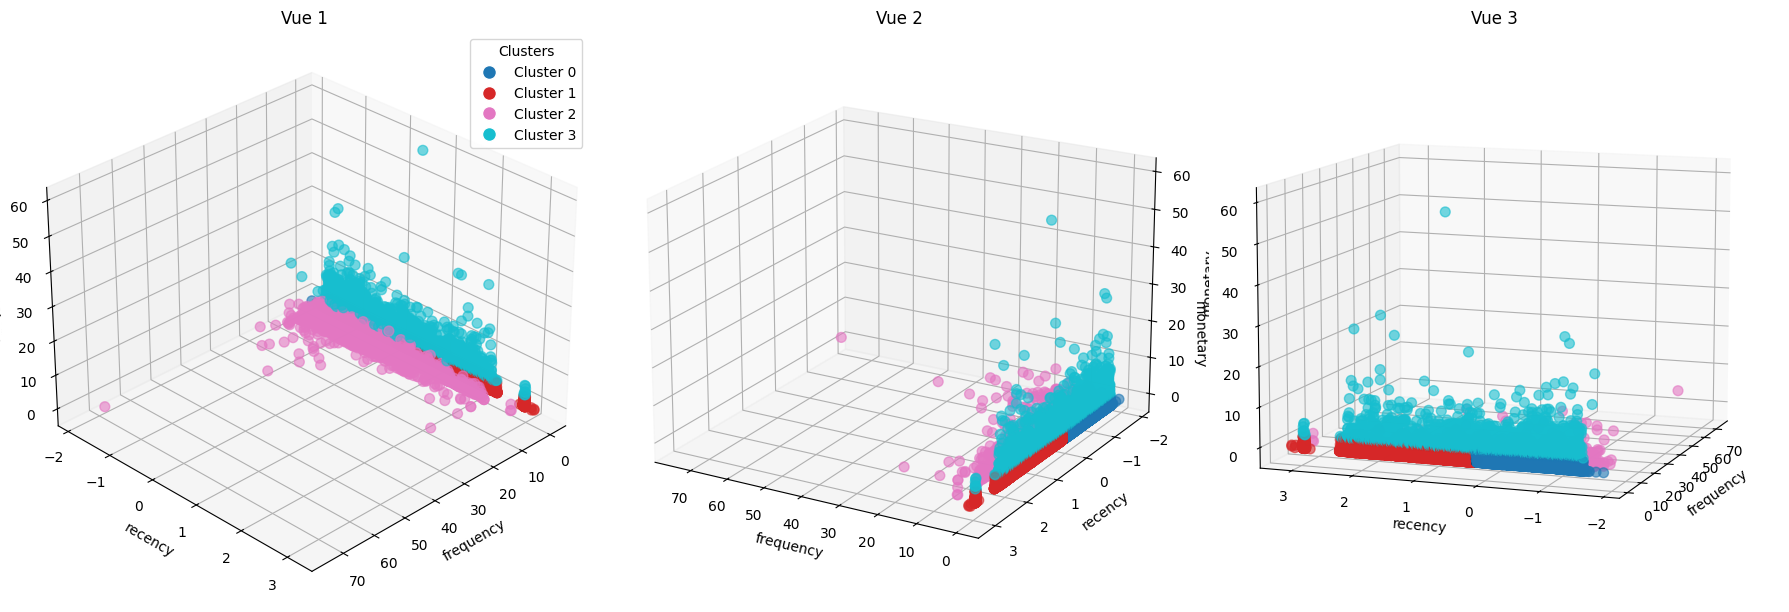

In [ ]:
# ==============================
# 4. AFFICHAGE 3D
# ==============================

# Choix des 3 variables à afficher
x_var, y_var, z_var = df_k_means_v1.columns[:3]

# Définition des angles pour les 3 vues
angles = [
    (30, 45, "Vue 1"),
    (20, 120, "Vue 2"),
    (10, 200, "Vue 3")
]

fig = plt.figure(figsize=(18, 6))

for i, (elev, azim, title) in enumerate(angles, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    # Scatter plot 3D
    scatter = ax.scatter(
        df_k_means_v1[x_var],
        df_k_means_v1[y_var],
        df_k_means_v1[z_var],
        c=df_k_means_v1['cluster'],
        cmap=plt.cm.tab10,
        alpha=0.6,
        s=50
    )
    
    # Axes
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.set_title(title)
    
    # Changer l’angle de vue
    ax.view_init(elev=elev, azim=azim)
    
    # Légende seulement sur le premier subplot
    if i == 1:
        unique_labels = np.sort(df_k_means_v1['cluster'].unique())
        legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=plt.cm.tab10(j/(len(unique_labels)-1)),
                   label=f"Cluster {l}", markersize=10)
            for j, l in enumerate(unique_labels)
        ]
        ax.legend(handles=legend_elements, title="Clusters")

plt.tight_layout()
plt.show()


### **ANALYSE DU CLUSTERING K-MEANS V1 (RFM SANS REVIEW_SCORE)**

____
**STRUCTURE DU JEU DE DONNÉES**

| Élément | Valeur |
|------|------|
| Taille du jeu de données | 96 096 lignes (clients) × 4 colonnes (variables) |
| Variables quantitatives | frequency, monetary, recency |
| Variable de segmentation | cluster |
| Standardisation | oui |
| Valeurs manquantes | 0 % |
| Zéros | 0 % (hors cluster) |
| Nombre de clusters | 4 |

Variables utilisées
- `frequency` : intensité d’achat
- `monetary` : valeur générée
- `recency` : récence d’achat (plus bas = plus récent)

____
**RÉPARTITION DES CLUSTERS**

| Cluster | Nb clients | Part |
|------|-----------|------|
| 0 | 52 073 | 54.2 % |
| 1 | 38 558 | 40.1 % |
| 2 | 2 963 | 3.1 % |
| 3 | 2 502 | 2.6 % |

→ Segmentation déséquilibrée  
Un cluster majoritaire très volumineux et plusieurs petits clusters à forte valeur et/ou fréquence.

____
**PROFIL MOYEN DES CLUSTERS (VARIABLES STANDARDISÉES)**

| Cluster | Recency | Monetary | Frequency |
|------|--------|----------|-----------|
| 0 | −0.72 | −0.13 | −0.16 |
| 1 | 0.98 | −0.14 | −0.16 |
| 2 | −0.13 | 0.53 | 5.05 |
| 3 | 0.01 | 4.39 | −0.09 |

____
**INTERPRÉTATION MÉTIER DES CLUSTERS**

**Cluster 0 — Clients majoritaires (54 %)**
- Recency moyenne (achats récents modérés)  
- Faible valeur et fréquence  
→ Clients **occasionnels**, peu contributeurs au chiffre d’affaires

**Cluster 1 — Clients (40 %)**
- Recency plus ancienne  
- Valeur et fréquence faibles  
→ Clients peu actifs et peu rentables

**Cluster 2 — Clients premium (3 %)**
- Recency moyenne  
- Valeur et fréquence élevées  
→ **Cœur de business**, clients fidèles et rentables

**Cluster 3 — Clients à forte valeur (2.6 %)**
- Très forte monetary  
- Frequency modérée  
→ Clients stratégiques sur valeur mais moins actifs

____
**ANALYSE DÉTAILLÉE PAR VARIABLE**

**Recency**
- Cluster 0 : dispersion large autour de −0.72  
- Cluster 1 : plus anciens, achats peu récents  
- Cluster 2 : légèrement plus récents  
- Cluster 3 : proche de la moyenne  

**Monetary**
- Cluster 3 : valeur très élevée, se distingue nettement  
- Cluster 2 : valeur modérée  
- Cluster 0 et 1 : valeur faible

**Frequency**
- Cluster 2 : variable structurante, très élevée  
- Cluster 0,1,3 : faible fréquence, presque constante dans cluster 0 et 1

____
**CONCLUSION GLOBALE**

- Clustering **déséquilibré**, 4 groupes mais deux dominants  
- Segmentation claire pour identifier le **petit cluster premium** et le **cluster à forte valeur**  
- Utile pour **identifier le cœur de business** et prioriser les clients stratégiques  
- Limité pour capturer toutes les nuances comportementales, notamment pour les clusters majoritaires


# **K-MEANS_V2**

### **FEATURE ENGINEERING**

In [46]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE (MONETARY)
# ============================================================

order_value = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),
        freight_total=('freight_value', 'sum')
    )
)
order_value['order_total_value'] += order_value['freight_total']


# ============================================================
# 2. ENRICHISSEMENT DES COMMANDES
# ============================================================

orders_rfm = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp']
)


# ============================================================
# 3. AGRÉGATION CLIENT — VARIABLES RFM
# ============================================================

df_rfm = (
    orders_rfm
    .groupby('customer_unique_id', as_index=False)
    .agg(
        frequency=('order_id', 'nunique'),
        monetary=('order_total_value', 'sum'),
        last_order_date=('order_purchase_timestamp', 'max')
    )
)

# ============================================================
# 4. CALCUL DE LA RECENCY
# ============================================================

reference_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    reference_date - df_rfm['last_order_date']
).dt.days


# ============================================================
# 5. AJOUT DU REVIEW_SCORE MOYEN PAR CLIENT
# ============================================================

# Agrégation review_score au niveau client
df_review_score = (
    order_reviews
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

# Moyenne du review_score par client
df_review_score = (
    df_review_score
    .groupby('customer_unique_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
)

# ============================================================
# 6. TABLE FINALE RFM + REVIEW
# ============================================================

df_review_score = df_rfm.merge(df_review_score, on='customer_unique_id', how='left')

# Optionnel : remplir les clients sans review par 0 ou NaN
df_review_score['review_score'] = df_review_score['review_score'].fillna(0)

# Vérification
df_review_score.head()


,customer_unique_id,frequency,monetary,last_order_date,recency,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,160,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,163,4.0
2,0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,585,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,369,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,336,5.0



=== Table : df_review_score ===
Taille : 96096 lignes × 6 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,1,int64,numérique,9,NaN,0.0,0.00,1,1.0,1.0,1.0,17,1.03
2,monetary,141.9,float64,numérique,31718,NaN,0.0,0.70,0.0,62.39,107.27,182.2375,13664.08,164.87
3,last_order_date,2018-05-10 10:56:27,datetime64[ns],date,95834,NaN,0.0,NaN,2016-09-04 21:15:19,2017-09-15 09:04:17.249999872,2018-01-21 19:39:16,2018-05-06 20:14:49.750000128,2018-10-17 17:30:18,NaN
4,recency,160,int64,numérique,630,NaN,0.0,0.00,0,163.0,268.0,397.0,772,287.74
5,review_score,5.0,float64,numérique,35,NaN,0.0,0.75,0.0,4.0,5.0,5.0,5.0,4.05


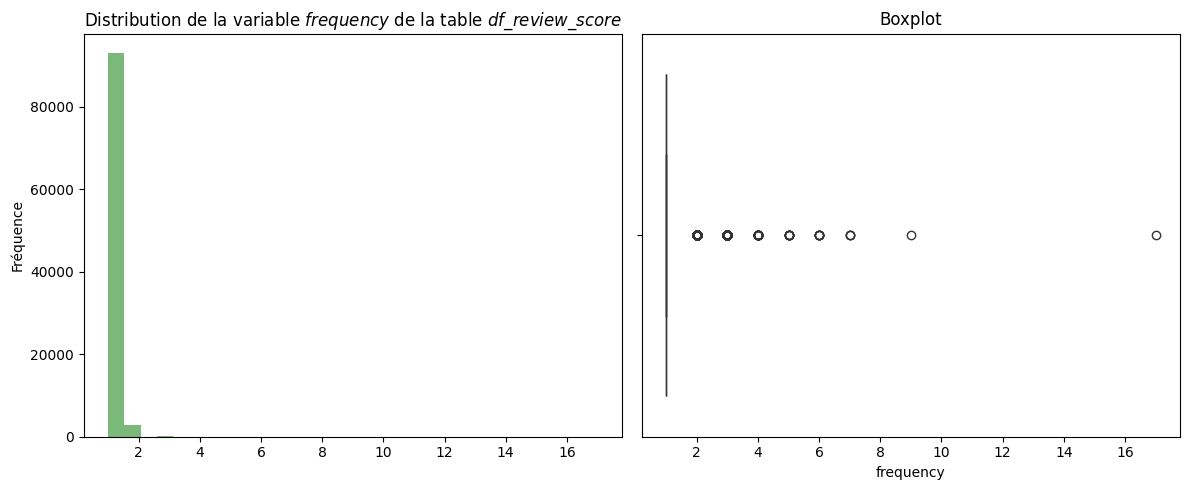

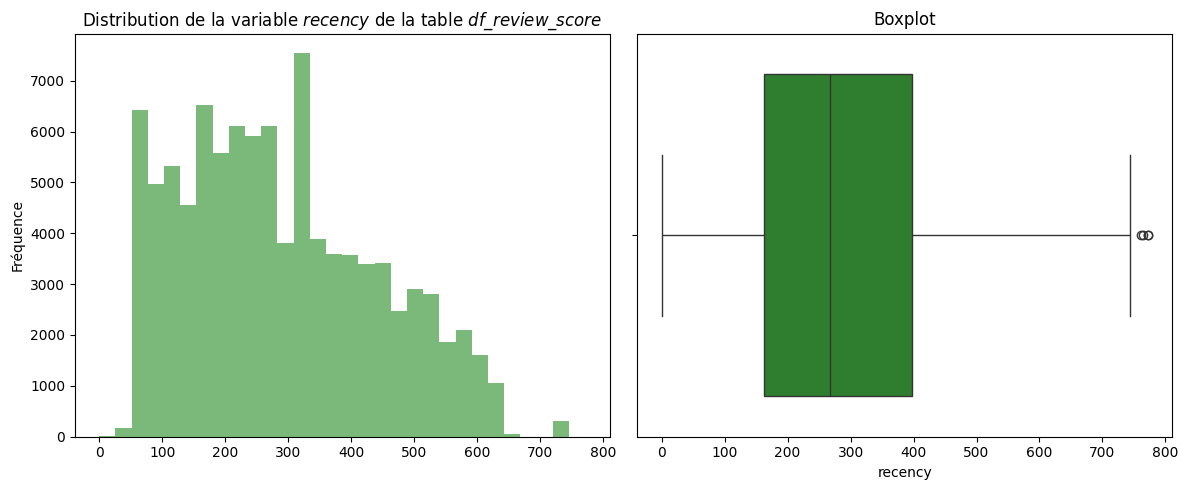

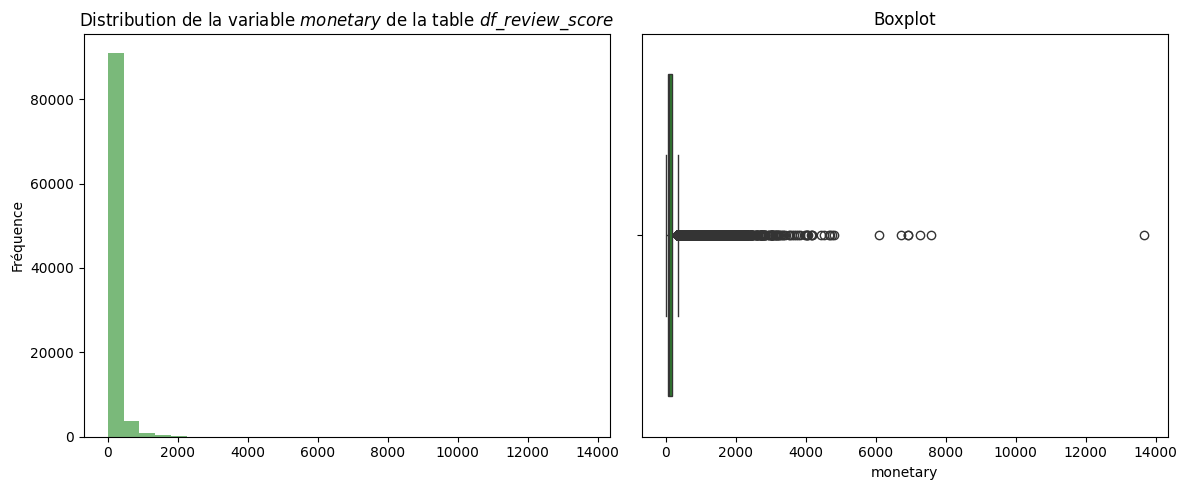

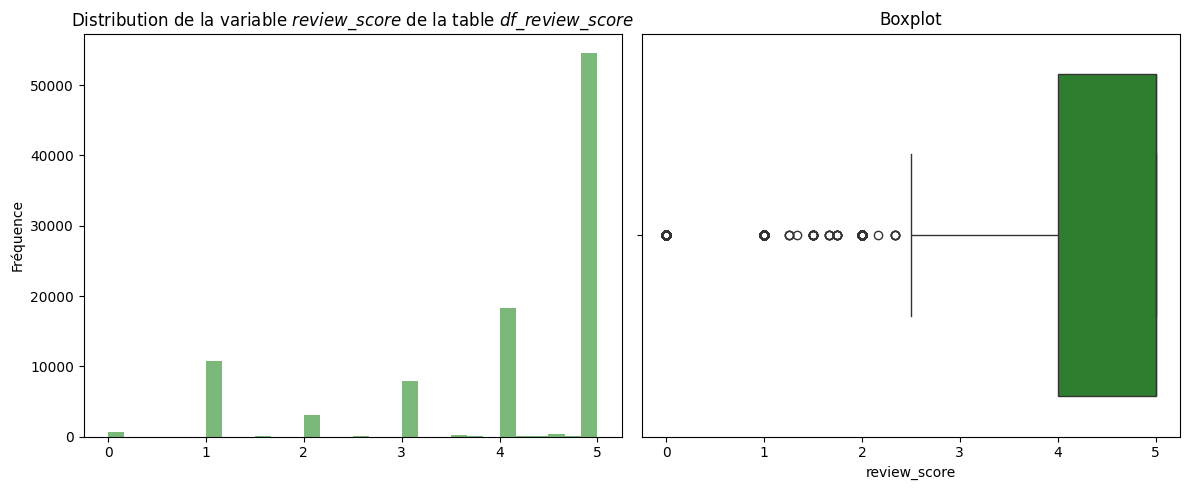

In [47]:
# ==============================
# PROFIL
# ==============================

# --- Profil du dataframe ---
profile_df_review_score = profile_dataframe(df_review_score, "df_review_score")
display(profile_df_review_score)

# --- Affichage des distributions ---
plot_distributions(df_review_score, ['frequency', 'recency', 'monetary', 'review_score'], table_name="df_review_score")

### **ENTRAÎNEMENT**

In [51]:
# ==============================
# PRÉPARATION DES DONNÉES POUR K-MEANS
# ==============================

# --- Copie de travail ---
df_k_means_v2 = df_review_score.copy()

# --- Exclusion explicite de l'identifiant ---
id_col = 'customer_unique_id'
df_k_means_v2 = df_k_means_v2.drop(columns=[id_col])

# --- Sélection uniquement des colonnes numériques ---
df_k_means_v2 = df_k_means_v2.select_dtypes(include=['int64', 'float64'])

# --- Standardisation des variables RFM ---
scaler = StandardScaler()
df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)

# --- Vérification finale ---
print("Shape df_k_means_v2 :", df_k_means_v2.shape)

profile_df_k_means_v2 = profile_dataframe(
    df_k_means_v2,
    "df_k_means_v2",
    primary_keys=None
)

display(profile_df_k_means_v2)

Shape df_k_means_v2 : (96096, 4)

=== Table : df_k_means_v2 ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


C:\Users\barre\AppData\Local\Temp\ipykernel_15664\2274742139.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.16236828 -0.16236828 -0.16236828 ... -0.16236828 -0.16236828
 -0.16236828]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)
C:\Users\barre\AppData\Local\Temp\ipykernel_15664\2274742139.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.83262149 -0.81306654  1.93766244 ...  2.14624852 -0.78047497
  1.59219173]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.0,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.0
1,monetary,-0.100783,float64,numérique,31227,NaN,0.0,0.0,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.0
2,recency,-0.832621,float64,numérique,630,NaN,0.0,0.0,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.0
3,review_score,0.684115,float64,numérique,35,NaN,0.0,0.0,-2.933729,-0.039454,0.684115,0.684115,0.684115,0.0


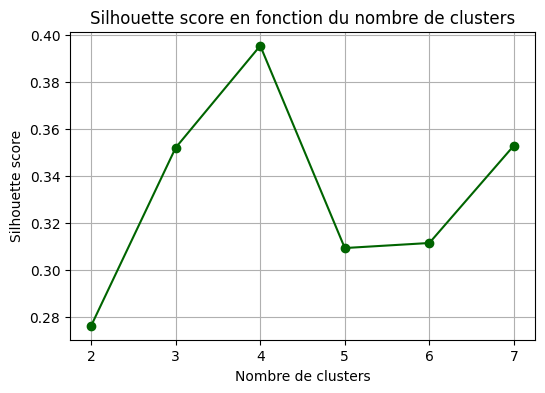

,n_clusters,silhouette_score
0,2,0.276229
1,3,0.352111
2,4,0.395550
3,5,0.309332
4,6,0.311486
5,7,0.352992


Nombre optimal de clusters selon silhouette : 4


In [53]:
# ==============================
# SILOUETTE SCORE
# ==============================

# --- Paramètres ---
range_n_clusters = range(2, 8)
silhouette_scores = []
random_state = 42  # Pour reproductibilité

# Préparer les données pour le clustering (ignore colonne cluster si elle existe)
df_for_clustering = df_k_means_v2.drop(columns=['cluster_init'], errors='ignore')

# --- Calcul des scores silhouette ---
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(df_for_clustering)
    score = silhouette_score(df_for_clustering, labels)
    silhouette_scores.append(score)

# --- Affichage de la courbe ---
plt.figure(figsize=(6,4))
plt.plot(
    range_n_clusters,
    silhouette_scores,
    marker='o',
    color='darkgreen'  # <-- couleur vert sapin
)
plt.title("Silhouette score en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# --- Tableau des résultats ---
results_df = pd.DataFrame({
    "n_clusters": list(range_n_clusters),
    "silhouette_score": silhouette_scores
})
display(results_df)

# --- Meilleur nombre de clusters selon silhouette ---
best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
print("Nombre optimal de clusters selon silhouette :", best_k)


n_clusters	silhouette_score
- 0	2	0.276229
- 1	3	0.352111
- 2	4	0.395550
- 3	5	0.309332
- 4	6	0.311486
- 5	7	0.352992

Nombre optimal de clusters selon silhouette : 4

In [48]:
# ==============================
# K-MEANS À 4 CLUSTERS
# ==============================

n_clusters_4 = 4
random_state = 42

# --- Fit KMeans 4 clusters ---
kmeans_rev_score_4_clusters = KMeans(n_clusters=n_clusters_4, random_state=random_state)
df_k_means_v2['cluster'] = kmeans_rev_score_4_clusters.fit_predict(df_k_means_v2.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_rev_score_4_clusters.inertia_
sil_score = silhouette_score(df_k_means_v2.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means_v2['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means_v2['cluster'].value_counts())

Inertia (somme des distances au centre) : 209184.18
Silhouette score : 0.367

Distribution des clusters :
cluster
0    42446
1    31886
2    19736
3     2028
Name: count, dtype: int64


In [49]:
# ==============================
# SAUVEGARDE DATAFRAME ET MODELE K-MEANS
# ==============================

# chemin raw string
path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# sauvegarde du DataFrame
df_k_means_v2.to_csv(f"{path_data}/df_k_means_v2.csv", index=False)

# sauvegarde du modèle KMeans
joblib.dump(kmeans_rev_score_4_clusters, f"{path_data}/kmeans_rev_score_4_clusters.joblib")

['C:\\Users\\barre\\Documents\\Pro\\Reconversion_professionnelle\\Formations\\Data_Scientist_by_Openclassrooms\\P05\\data/kmeans_rev_score_4_clusters.joblib']

In [50]:
# ==============================
# RECHARGEMENT DATAFRAME ET MODELE K-MEANS
# ==============================

path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# rechargement du DataFrame
df_k_means_v2 = pd.read_csv(f"{path_data}/df_k_means_v2.csv")

# rechargement du modèle
kmeans_rev_score_4_clusters = joblib.load(f"{path_data}/kmeans_rev_score_4_clusters.joblib")

### **INTERPRÉTATION DES CLUSTERS**


=== Table : df_k_means_v2 ===
Taille : 96096 lignes × 5 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.00,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.00
1,monetary,-0.100783,float64,numérique,30586,NaN,0.0,0.00,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.00
2,recency,-0.832621,float64,numérique,630,NaN,0.0,0.00,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.00
3,review_score,0.684115,float64,numérique,35,NaN,0.0,0.00,-2.933729,-0.039454,0.684115,0.684115,0.684115,0.00
4,cluster,0.000000,int64,numérique,4,NaN,0.0,44.17,0.000000,0.000000,1.000000,1.000000,3.000000,0.81


,recency,monetary,frequency,review_score
cluster,,,,
0,-0.76,-0.14,-0.16,0.43
1,1.00,-0.13,-0.16,0.41
2,0.02,0.00,0.59,-1.59
3,-0.01,4.93,0.18,-0.07


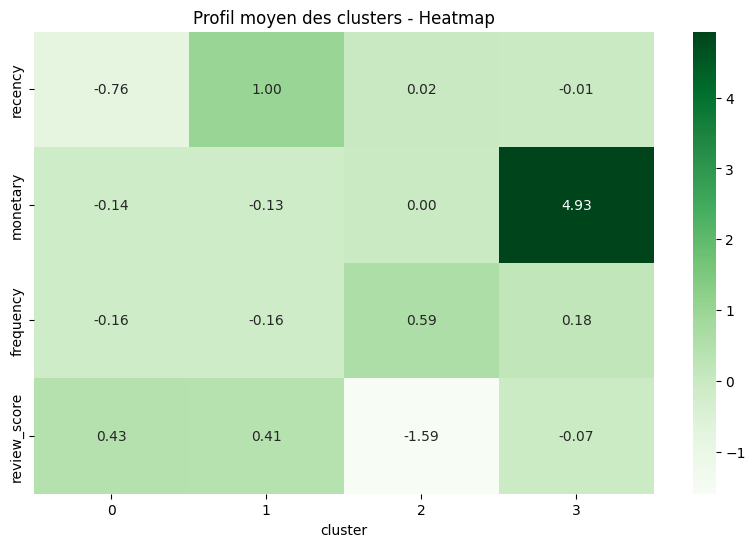

In [52]:
# ==============================
# 1. PROFIL DU DATAFRAME
# ==============================

# Profil complet du dataframe
df_profile = profile_dataframe(df_k_means_v2, table_name="df_k_means_v2")
display(df_profile)

# Profil moyen par cluster pour toutes les variables continues
cols_continuous = ['recency', 'monetary', 'frequency', 'review_score']
cols_continuous = [c for c in cols_continuous if c in df_k_means_v2.columns]

cluster_means = df_k_means_v2.groupby('cluster')[cols_continuous].mean().round(2)
display(cluster_means)

# Heatmap du profil moyen
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="Greens")
plt.title("Profil moyen des clusters - Heatmap")
plt.show()


,cluster,nb_clients
0,0,42446
1,1,31886
2,2,19736
3,3,2028


C:\Users\barre\AppData\Local\Temp\ipykernel_14884\1313166627.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x, y=y, palette=colors)


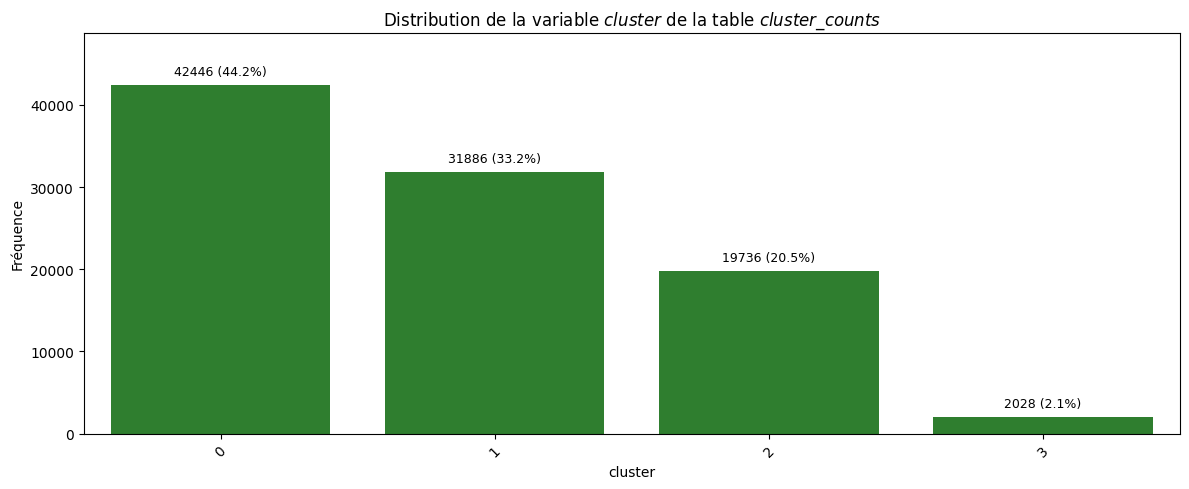

In [54]:
# ==============================
# 2. RÉPARTITION DES CLIENTS
# ==============================

# Tableau chiffré des effectifs
cluster_counts = df_k_means_v2['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'nb_clients']
display(cluster_counts)

# Barplot
plot_distributions(
    df=cluster_counts,
    columns=["cluster"],                # colonne catégorielle à tracer
    table_name="cluster_counts",
    show_values={"cluster": "both"},    # affiche count + %
    agg_col="nb_clients"                # colonne contenant les effectifs
)


cluster,0,1,2,3
count,42446.00,31886.00,19736.00,2028.00
mean,-0.76,1.00,0.02,-0.01
std,0.47,0.62,0.89,1.00
min,-1.59,0.10,-1.88,-1.54
25%,-1.17,0.46,-0.55,-0.84
50%,-0.77,0.93,-0.10,-0.13
75%,-0.36,1.47,0.46,0.73
max,0.13,2.97,3.16,2.96


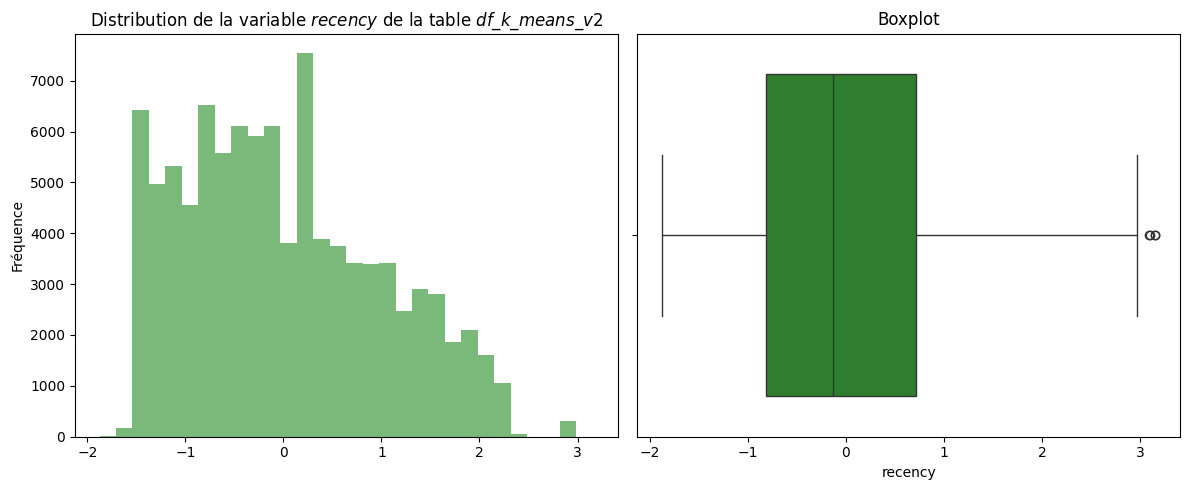

cluster,0,1,2,3
count,42446.00,31886.00,19736.00,2028.00
mean,-0.14,-0.13,0.00,4.93
std,0.49,0.50,0.63,3.09
min,-0.72,-0.72,-0.72,2.33
25%,-0.46,-0.46,-0.43,3.12
50%,-0.28,-0.28,-0.18,3.97
75%,0.01,0.00,0.20,5.58
max,2.71,2.87,4.42,59.22


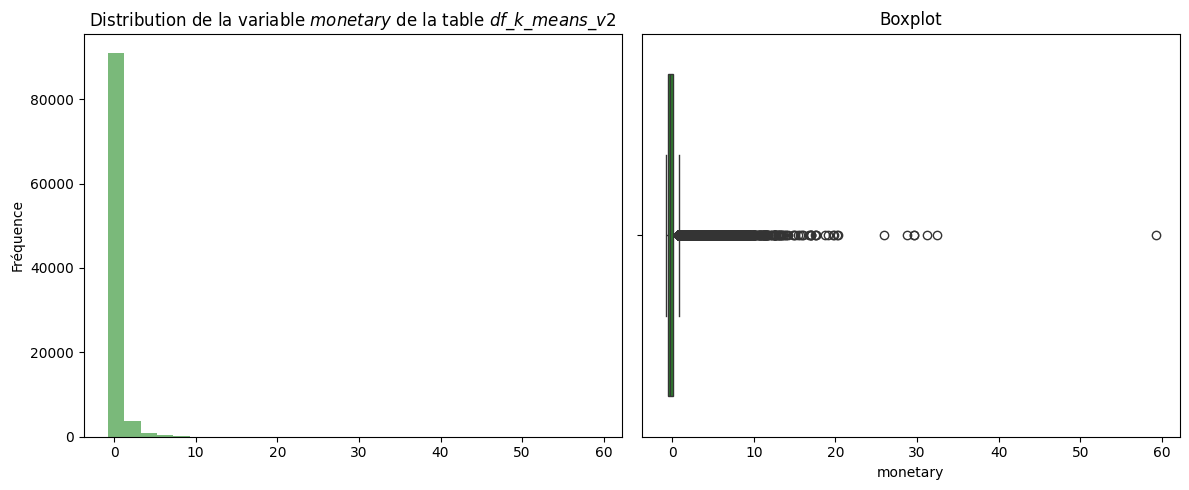

cluster,0,1,2,3
count,42446.00,31886.00,19736.00,2028.00
mean,-0.16,-0.16,0.59,0.18
std,0.00,0.03,2.04,1.53
min,-0.16,-0.16,-0.16,-0.16
25%,-0.16,-0.16,-0.16,-0.16
50%,-0.16,-0.16,-0.16,-0.16
75%,-0.16,-0.16,-0.16,-0.16
max,-0.16,4.50,74.47,18.50


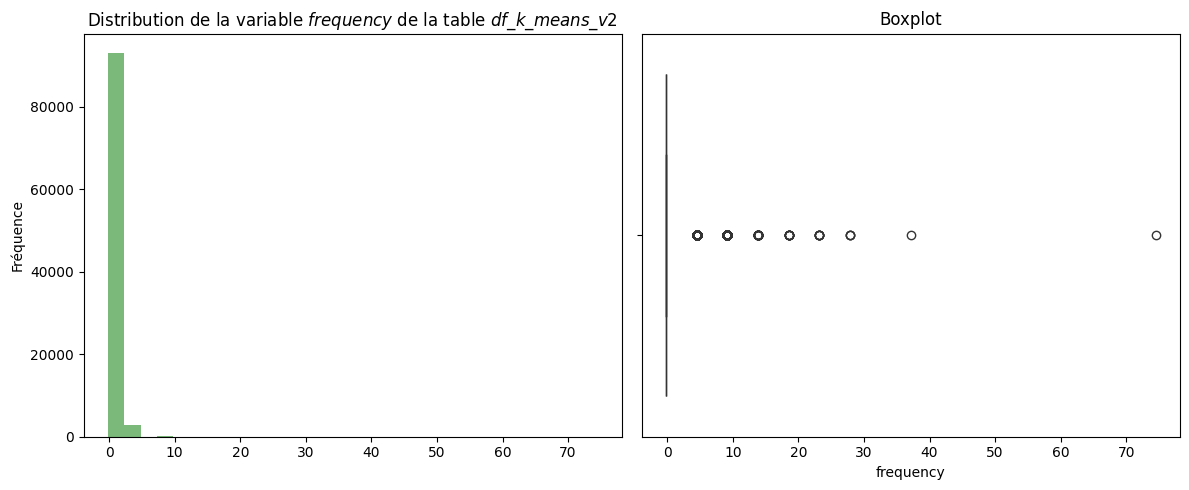

cluster,0,1,2,3
count,42446.00,31886.00,19736.00,2028.00
mean,0.43,0.41,-1.59,-0.07
std,0.42,0.44,0.93,1.07
min,-0.76,-1.49,-2.93,-2.93
25%,-0.04,-0.04,-2.21,-0.76
50%,0.68,0.68,-2.21,0.68
75%,0.68,0.68,-0.76,0.68
max,0.68,0.68,0.68,0.68


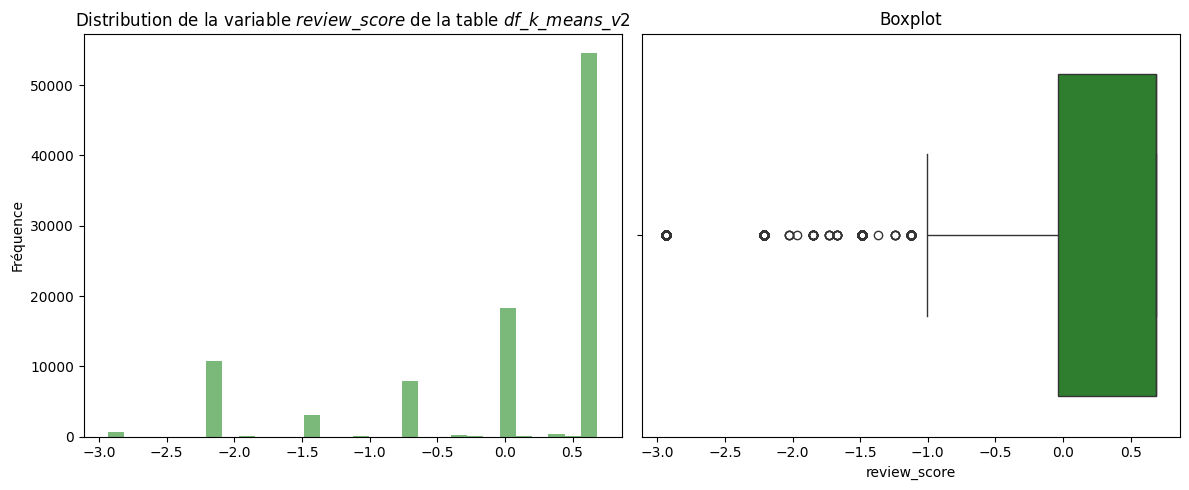

In [59]:
# ==============================
# 3. DISTRIBUTIONS DES VARIABLES
# ==============================

features_to_plot = ['recency', 'monetary', 'frequency', 'review_score']
features_to_plot = [f for f in features_to_plot if f in df_k_means_v2.columns]

# Boucle boxplots + tableau chiffré
for feature in features_to_plot:
    # Tableau descriptif par cluster
    desc = df_k_means_v2.groupby('cluster')[feature].describe().T.round(2)
    display(desc)

    # Boxplot
    plot_distributions(
        df=df_k_means_v2,
        columns=feature,
        table_name="df_k_means_v2"
    )


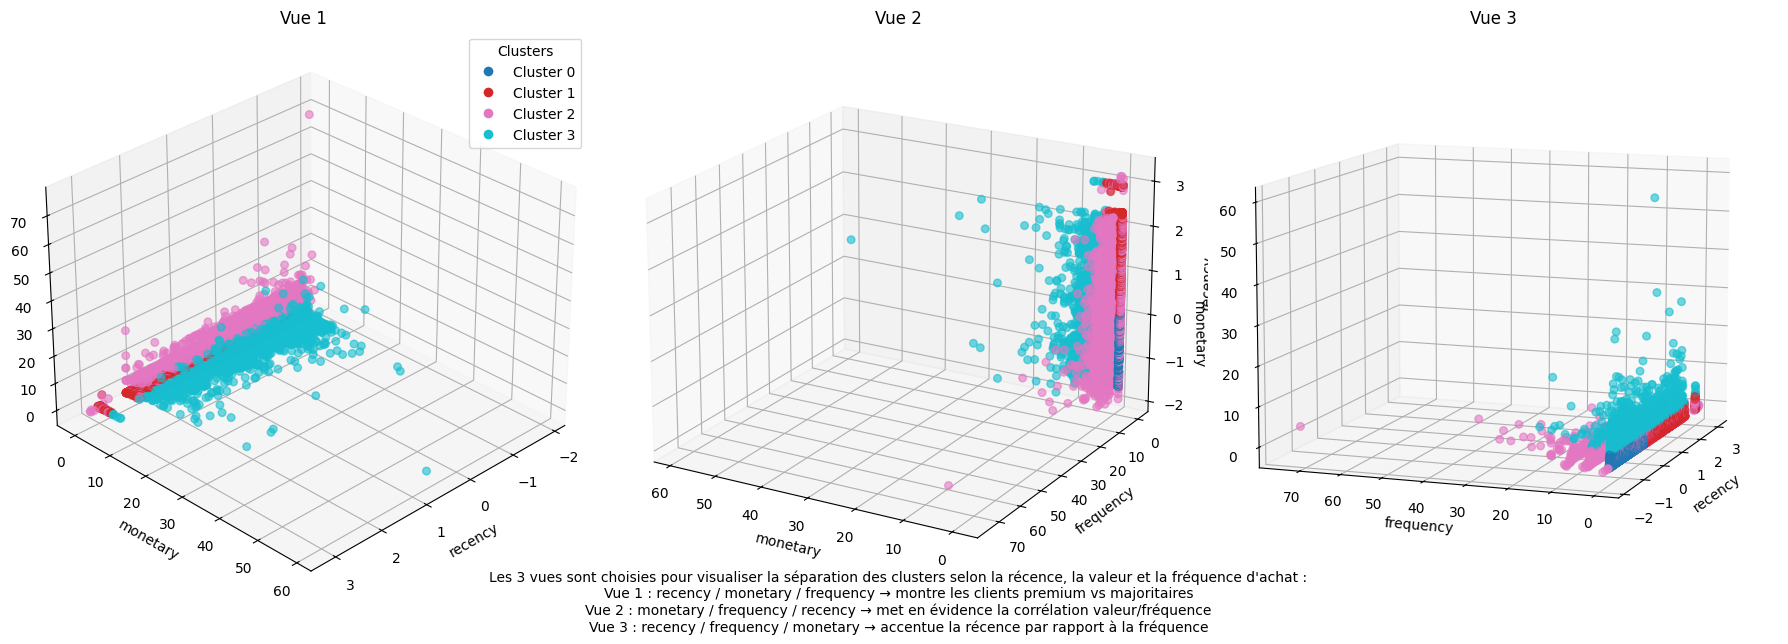

In [ ]:
# ==============================
# 4. VISUALISATION 3D DES CLUSTERS
# ==============================

# Variables à afficher pour chaque vue
views = [
    ("recency", "monetary", "frequency", "Vue 1"),
    ("monetary", "frequency", "recency", "Vue 2"),
    ("recency", "frequency", "monetary", "Vue 3")
]

fig = plt.figure(figsize=(18,6))
cmap = plt.cm.tab10

for i, (x_var, y_var, z_var, title) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')

    # Scatter plot
    scatter = ax.scatter(
        df_k_means_v2[x_var],
        df_k_means_v2[y_var],
        df_k_means_v2[z_var],
        c=df_k_means_v2['cluster'],
        cmap=cmap,
        alpha=0.6,
        s=30
    )

    # Axes
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.set_title(title)

    # Ajustement angles pour chaque vue
    if i == 1:
        ax.view_init(elev=30, azim=45)
    elif i == 2:
        ax.view_init(elev=20, azim=120)
    elif i == 3:
        ax.view_init(elev=10, azim=200)

    # Légende uniquement sur le premier subplot
    if i == 1:
        unique_labels = np.sort(df_k_means_v2['cluster'].unique())
        legend_elements = [
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=cmap(j/(len(unique_labels)-1)),
                   label=f"Cluster {l}", markersize=8)
            for j,l in enumerate(unique_labels)
        ]
        ax.legend(handles=legend_elements, title="Clusters")

plt.tight_layout()

# Commentaire explicatif sous les 3 vues
plt.figtext(
    0.5, -0.02,
    "Les 3 vues sont choisies pour visualiser la séparation des clusters "
    "selon la récence, la valeur et la fréquence d'achat :\n"
    "Vue 1 : recency / monetary / frequency → montre les clients premium vs majoritaires\n"
    "Vue 2 : monetary / frequency / recency → met en évidence la corrélation valeur/fréquence\n"
    "Vue 3 : recency / frequency / monetary → accentue la récence par rapport à la fréquence",
    wrap=True, ha='center', fontsize=10
)

plt.show()


### **ANALYSE DU CLUSTERING K-MEANS V2 (RFM + REVIEW_SCORE)**

____
**STRUCTURE DU JEU DE DONNÉES**

| Élément | Valeur |
|------|------|
| Taille du jeu de données | 96 096 lignes (clients) × 5 colonnes (variables) |
| Variables quantitatives | frequency, monetary, recency, review_score |
| Variable de segmentation | cluster |
| Standardisation | oui |
| Valeurs manquantes | 0 % |
| Zéros | 0 % (hors cluster) |
| Nombre de clusters | 4 |

Variables utilisées
- `frequency` : intensité d’achat
- `monetary` : valeur générée
- `recency` : récence d’achat (plus bas = plus récent)
- `review_score` : satisfaction client

____
**RÉPARTITION DES CLUSTERS**

| Cluster | Nb clients | Part |
|------|-----------|------|
| 0 | 42 446 | 44.2 % |
| 1 | 31 886 | 33.2 % |
| 2 | 19 736 | 20.5 % |
| 3 | 2 028 | 2.1 % |

→ Segmentation très déséquilibrée  
Un cluster majoritaire et plusieurs petits clusters à forte valeur et/ou fréquence.

____
**PROFIL MOYEN DES CLUSTERS (VARIABLES STANDARDISÉES)**

| Cluster | Recency | Monetary | Frequency | Review_score |
|------|--------|----------|-----------|--------------|
| 0 | −0.76 | −0.14 | −0.16 | 0.43 |
| 1 | 1.00 | −0.13 | −0.16 | 0.41 |
| 2 | 0.02 | 0.00 | 0.59 | −1.59 |
| 3 | −0.01 | 4.93 | 0.18 | −0.07 |

____
**INTERPRÉTATION MÉTIER DES CLUSTERS**

**Cluster 0 — Clients majoritaires (44 %)**
- Recency faible/modérée (achats récents)  
- Faible valeur et fréquence  
- Satisfaction correcte  
→ Clients **occasionnels**, peu contributeurs au chiffre d’affaires

**Cluster 1 — Clients (33 %)**
- Achats plus anciens  
- Valeur et fréquence faibles  
- Satisfaction correcte  
→ Clients peu actifs et à **réactiver**

**Cluster 2 — Clients à forte fréquence mais insatisfaits (20 %)**
- Recency moyenne  
- Frequency modérée mais Review_score très faible  
→ Segment à risque, prioritaire pour actions correctives

**Cluster 3 — Clients premium à forte valeur (2 %)**
- Très forte monetary  
- Frequency modérée  
- Satisfaction neutre  
→ Clients stratégiques et rentables

____
**ANALYSE DÉTAILLÉE PAR VARIABLE**

**Recency**
- Cluster 0 : achats récents  
- Cluster 1 : achats anciens  
- Clusters 2 et 3 : dispersion plus large autour de la moyenne  

**Monetary**
- Cluster 3 se distingue fortement (valeur maximale très élevée)  
- Cluster 2 : valeur modérée  
- Clusters 0 et 1 : faible valeur

**Frequency**
- Cluster 2 : variable structurante, fréquence modérée à élevée  
- Clusters 0 et 1 : fréquence quasi constante et faible  
- Cluster 3 : fréquence faible/modérée

**Review_score**
- Cluster 2 : fortement négatif → insatisfaction marquée  
- Clusters 0 et 1 : bien notés  
- Cluster 3 : neutre, performance business ≠ satisfaction maximale

____
**CONCLUSION GLOBALE**

- Clustering **déséquilibré**, 4 groupes mais un cluster majoritaire dominant  
- Segmentation claire pour identifier :
  - le petit cluster premium à forte valeur  
  - le cluster à fréquence élevée mais insatisfait  
- Utile pour **prioriser actions marketing et fidélisation**  
- Limité pour capturer toutes les nuances comportementales, notamment dans les clusters majoritaires


### **COMPARAISON DES 2 VERSIONS DE K-MEANS V2 : SANS ET AVEC REVIEW_SCORE**

___
**STRUCTURE ET VARIABLES**

| Aspect | K-means v1 | K-means v2 |
|--------|------------|------------|
| Nombre de variables | 3 (frequency, monetary, recency) | 4 (frequency, monetary, recency, review_score) |
| Nombre de clusters | 4 | 4 |
| Standardisation | Oui | Oui |

- L’ajout de `review_score` dans la v2 permet d’intégrer une dimension qualitative (satisfaction client) qui n’existait pas dans la v1.  
- La v1 se concentre uniquement sur le comportement d’achat et la valeur, tandis que la v2 capture également la perception client.

___
**SEGMENTATION**

| Aspect | K-means v1 | K-means v2 |
|--------|------------|------------|
| Cluster majoritaire | 54 % | 44 % |
| Cluster premium | 3 % | 2 % |
| Nombre de clusters intermédiaires | 2 | 2 (clients à réactiver, clients insatisfaits) |
| Équilibre | Très déséquilibré | Plus nuancé, mais toujours déséquilibré |

- La v2 permet d’identifier des segments intermédiaires, invisibles dans la v1, grâce à l’inclusion de `review_score`.  
- Le cluster premium reste similaire en taille et profil dans les deux versions.

___
**INTERPRÉTABILITÉ MÉTIER**

- **V1** : distinction simple entre clients majoritaires peu actifs et clients premium → utile pour repérer le cœur de business, mais insuffisant pour stratégie marketing segmentée.  
- **V2** : segmentation plus fine permet d’identifier :
  - clients à réactiver (anciens mais satisfaits)  
  - clients insatisfaits (risque potentiel)  
  - clients occasionnels récents  
  → Facilite des actions marketing ciblées et prioritaires selon la valeur et la satisfaction.

___
**ANALYSE DES VARIABLES ET PROFILS DES CLUSTERS**

| Variable | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|----------|-----------|-----------|-----------|-----------|
| **V1 - Recency** | −0.72 | 0.98 | −0.13 | 0.01 |
| **V1 - Monetary** | −0.13 | −0.14 | 0.53 | 4.39 |
| **V1 - Frequency** | −0.16 | −0.16 | 5.05 | −0.09 |
| **V2 - Recency** | −0.76 | 1.00 | 0.02 | −0.01 |
| **V2 - Monetary** | −0.14 | −0.13 | 0.00 | 4.93 |
| **V2 - Frequency** | −0.16 | −0.16 | 0.59 | 0.18 |
| **V2 - Review_score** | 0.43 | 0.41 | −1.59 | −0.07 |

- V2 montre des nuances importantes : le cluster 2 présente une fréquence modérée mais une insatisfaction très marquée (`review_score` négatif).  
- Le cluster 3 reste le cœur de business avec forte valeur, fréquence modérée et satisfaction neutre.

___
**CONCLUSIONS COMPARATIVES**

- **V1 (sans review_score)** :
  - Simplicité et forte distinction du cluster premium  
  - Limité pour détecter les nuances de comportement ou insatisfaction  
  - Adapté à une analyse rapide de valeur/fidélité  

- **V2 (avec review_score)** :
  - Segmentation plus riche et interprétable  
  - Identification de segments stratégiques (à réactiver, insatisfaits)  
  - Permet d’intégrer la perception client dans les décisions marketing  

**→ Synthèse** : L’ajout de `review_score` transforme le clustering de simple distinction "premium / non-premium" en une segmentation exploitable pour la stratégie marketing, tout en conservant l’identification claire du cœur de business.


DBSCAN

agglomerative clustering > a faire sur un échantillon (15/25%) si ça prend trop de temps

MAINTENANCE
Si nouveaux clients ou comportements différents des anciens > clustering obsolete
- tester sur une fréquence de réentrainement du k-means toutes les semaines
- faire un ARI score pour chaque nouvelle version des k-means VS k-means initial
- on teste par pas de 7 jours → ARI <0.8
- on en concluera la périodicité de réentrainement pour la maintenance

1. mettre à jour le nb de clusters de la V1
2. ne pas faire de PCA
3. changer les hyperparamétres, en plus du silouette score pour valider le nb de clusters (CE3 et CE4)
3. mettre à jour les analyses avec nouveau nb de cluster + choix des hyperparamétres
4. tester avec DBSCAn et agglomerative clustering
5. faire la maintenance